# Prétraitement EEG et extraction de bandpower

Ce notebook a pour objectif de prétraiter des fichiers EEG au format `.edf`, de sélectionner les canaux communs entre les participants, d’appliquer les étapes standards de prétraitement (référenciation, filtrage, épocage), puis d’extraire des caractéristiques spectrales de type **bandpower** pour des analyses de classification.

Les données proviennent de deux groupes :
- **H** : participants sains
- **MDD** : participants avec dépression majeure

Les sorties finales sauvegardées sont :
- `X_epochs_data.npy` : données EEG épocées
- `X_features.npy` : caractéristiques de bandpower
- `y_epoch_labels.npy` : étiquettes de groupe

## 1. Importation des librairies

Cette section importe les librairies nécessaires pour :
- manipuler les chemins et fichiers (`os`, `Path`)
- traiter les données EEG (`mne`, `mne_bids`)
- effectuer des calculs numériques (`numpy`)
- visualiser les données (`matplotlib`)
- compter la fréquence d’apparition des canaux (`Counter`)
- calculer la densité spectrale de puissance avec la méthode de Welch (`psd_array_welch`)

In [ ]:
import os
import mne
from pathlib import Path
import mne_bids
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mne.time_frequency import psd_array_welch

## 2. Définition des dossiers d’entrée et de sortie

- `source_data_dir` contient les données brutes
- `output_data_dir` contiendra les fichiers prétraités et les caractéristiques extraites

In [3]:
source_data_dir = os.environ.get("SOURCE_DATA_DIR", "source_data")
output_data_dir = os.environ.get("OUTPUT_DATA_DIR", "output_data")

## 3. Chargement du jeu de données

Dans cette section :
1. on localise les fichiers EEG `.edf`
2. on les trie pour conserver un ordre cohérent
3. on extrait la condition (**EC**, **EO** et **Task**) depuis le nom du fichier 
4. on identifie les fichiers appartenant au groupe **H** et au groupe **MDD**
5. on charge chaque fichier avec MNE
6. on extrait les informations sur les canaux pour identifier les canaux communs à tous les enregistrements

In [4]:
# Chemin vers le dossier contenant les fichiers EEG
edf_folder = os.path.join(source_data_dir, "4244171")

# Sélection des fichiers .edf pour les conditions EC, EO et Task
conditions = ('EC.edf', 'EO.edf', 'Task.edf')
edf_files = [f for f in os.listdir(edf_folder) if f.endswith(conditions)]

# Fonction de tri des fichiers
def sort_key(filename):
    """
    L'idée est de placer d'abord les fichiers H, puis les fichiers MDD, tout en respectant l'ordre numérique des identifiants.
    """
    file_type = 0 if 'H' in filename.upper() else 1
    num = int(''.join(filter(str.isdigit, filename)))
    return (file_type, num)

edf_files.sort(key=sort_key)

# Extraire la condition depuis le nom de fichier
def get_condition(filename):
    for cond in ['EC', 'EO', 'Task']:
        if filename.endswith(f'{cond}.edf'):
            return cond
    return 'Unknown'

# Classification des fichiers selon le groupe
mdd_files = [f for f in edf_files if 'MDD' in f.upper()]  # MDD: groupe dépression
h_files = [f for f in edf_files if 'H' in f.upper()]      # H: groupe contrôle

print(f"Found {len(mdd_files)} MDD files and {len(h_files)} H files.")  # 30 MDD files, 28 H files
print(f"MDD files: {mdd_files}") 
print(f"H files: {h_files}")

# Chargement des fichiers EEG
raw_list = [] # contiendra les objets Raw de MNE
channel_info = []  # channels name and band channel info of each files
all_channels = set() 
condition_labels = []

for edf_file in edf_files:
    edf_path = os.path.join(edf_folder, edf_file)
    raw = mne.io.read_raw_edf(edf_path, preload=True)
    raw_list.append(raw)
    condition_labels.append(get_condition(edf_file))

    ch_names = raw.ch_names
    bads = raw.info['bads']
    channel_info.append({'file': edf_file, 'channels': ch_names, 'bads': bads})
    all_channels.update(ch_names)

print(f"Successfully loaded {len(raw_list)} EEG files!")

# Compter combien de fois chaque canal apparaît dans les fichiers
# Permet d'identifier les canaux communs à tous les enregistrements
channel_counts = Counter()
for info in channel_info:
    channel_counts.update(info['channels'])
    
# Canaux présents dans tous les fichiers (c'est-à-dire ceux dont le compte est égal au nombre total de fichiers)
common_channels = [ch for ch, count in channel_counts.items() if count == len(edf_files)]

print(f"Common channels across all files: {common_channels} (Count: {len(common_channels)})")

# Calculer le nombre de canaux fonctionnels ou défectueux parmi les fichiers
for info in channel_info:
    good_channels = [ch for ch in info['channels'] if ch not in info['bads']]
    print(f"File: {info['file']}, Good Channels: {len(good_channels)}, Bad Channels: {len(info['bads'])}, Total: {len(info['channels'])}")

# Visualiser les canaux défectueux
bad_channel_freq = Counter()
for info in channel_info:
    bad_channel_freq.update(info['bads'])
print("Bad channel frequency:", dict(bad_channel_freq))

FileNotFoundError: [Errno 2] No such file or directory: 'source_data/4244171'

## 4. Visualisation des données brutes

Cette étape permet d’inspecter visuellement un enregistrement EEG avant le prétraitement :
- qualité générale du signal
- présence d’artefacts
- longueur de l’enregistrement
- organisation des canaux

Ici, on affiche simplement le premier fichier chargé à titre d’exemple.

In [4]:
raw_list[0].plot()

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x600002f0c600) at 0x1a7dea940>

## 5. Inspection des métadonnées

La structure `info` de MNE contient les informations importantes sur l’enregistrement :
- nom des canaux
- fréquence d’échantillonnage
- type des canaux
- système de référence
- etc.

Cette inspection est utile pour vérifier que les fichiers sont cohérents entre eux.

Canaux communs dans tous les fichiers : ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'] (N = 20)

In [5]:
raw_list[0].info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-LE, EEG F3-LE, EEG C3-LE, EEG P3-LE, EEG O1-LE, EEG ...
 chs: 22 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 80.0 Hz
 meas_date: 2011-08-16 17:48:54 UTC
 nchan: 22
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Ahmed_J_0816011, sex: 1, last_name: XX, birthday: 1987-01-20>
>

In [6]:
raw_list[0].info.keys()

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])

In [7]:
for key in raw_list[0].info.keys():
    print(f"{key}: {raw_list[0].info[key]}")

acq_pars: None
acq_stim: None
ctf_head_t: None
description: None
dev_head_t: None
dev_ctf_t: None
dig: None
experimenter: None
utc_offset: None
device_info: None
file_id: None
highpass: 0.5
hpi_subsystem: None
kit_system_id: None
helium_info: None
line_freq: None
lowpass: 80.0
meas_date: 2011-08-16 17:48:54+00:00
meas_id: None
proj_id: None
proj_name: None
subject_info: <subject_info | his_id: Ahmed_J_0816011, sex: 1, last_name: XX, birthday: 1987-01-20>
xplotter_layout: None
gantry_angle: None
bads: []
chs: [{'cal': 1.0, 'logno': 1, 'scanno': 1, 'range': 1.0, 'unit_mul': 0 (FIFF_UNITM_NONE), 'ch_name': 'EEG Fp1-LE', 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'coil_type': 1 (FIFFV_COIL_EEG), 'kind': 2 (FIFFV_EEG_CH), 'loc': array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])}, {'cal': 1.0, 'logno': 2, 'scanno': 2, 'range': 1.0, 'unit_mul': 0 (FIFF_UNITM_NONE), 'ch_name': 'EEG F3-LE', 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'c

In [8]:
raw_list[0].info['custom_ref_applied']

0 (FIFFV_MNE_CUSTOM_REF_OFF)

## 6. Sélection des canaux communs

Tous les fichiers ne contiennent pas exactement les mêmes canaux.  
Pour standardiser les données entre les participants, on conserve uniquement les canaux communs.

Ici, le canal de référence `EEG A2-A1` est exclu afin de ne garder que les 19 canaux EEG d’intérêt.

In [9]:
common_channels_with_ref = ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
                           'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE',
                           'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE',
                           'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE']

# Conserver seulement les 19 canaux EEG sélectionnés
raw.pick_channels(common_channels_with_ref) 

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | MDD S34 EC.edf, 19 x 76288 (298.0 s), ~11.1 MiB, data loaded>

## 7. Renommage des canaux

Les noms de canaux d’origine contiennent le préfixe `EEG` et le suffixe `-LE`.  
Pour simplifier les analyses et assurer la compatibilité avec le montage standard 10-20, les canaux sont renommés en format plus classique (ex. `EEG Fp1-LE` devient `Fp1`).

In [10]:
# Création d'une version simplifiée des noms de canaux
common_channels = [ch.replace('-LE', '').replace('EEG ', '') for ch in common_channels_with_ref]

# Renommage des canaux dans l'objet Raw
raw.rename_channels({ch: ch.replace('-LE', '').replace('EEG ', '') for ch in common_channels_with_ref}) 

<RawEDF | MDD S34 EC.edf, 19 x 76288 (298.0 s), ~11.1 MiB, data loaded>

## 8. Visualisation de la disposition des électrodes

Cette étape associe les canaux EEG au montage standard international **10-20**, puis affiche leur position sur le scalp.

Cela permet de vérifier que les noms de canaux sont correctement reconnus par MNE.

In [11]:
print(raw.ch_names)

['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz']


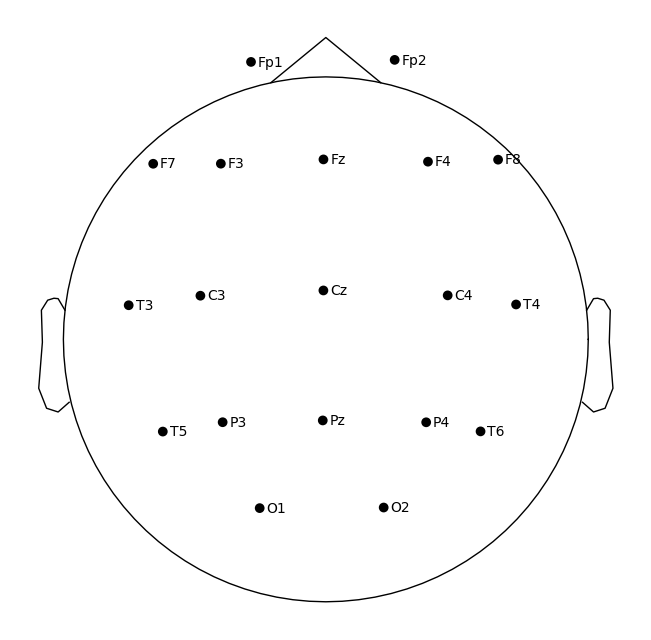

In [12]:
channel_mapping = {
    'EEG F7-LE': 'F7',
    'EEG T3-LE': 'T3',
    'EEG T5-LE': 'T5',
    'EEG Fz-LE': 'Fz',
    'EEG F8-LE': 'F8',
    'EEG T4-LE': 'T4',
    'EEG T6-LE': 'T6',
    'EEG Cz-LE': 'Cz',
    'EEG Pz-LE': 'Pz',
}

montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore', verbose=False)

raw.plot_sensors(kind='topomap', show_names=True)
plt.show()

In [13]:

raw_list = [mne.io.read_raw_edf(os.path.join(edf_folder, f), preload=True)
            .pick_channels(common_channels_with_ref)
            .rename_channels({ch: ch.replace('-LE', '').replace('EEG ', '') for ch in common_channels_with_ref})
            .set_montage(montage, verbose=False) 
            for f in edf_files]

print(f"Successfully loaded and processed {len(raw_list)} files with 19 channels each.")

Extracting EDF parameters from /Users/oceanevallee/PSY3019/Projet final/Vallee_ProjetFinal/source_data/4244171/H S1 EC.edf...


Setting channel info structure...


Creating raw.info structure...


Reading 0 ... 76799  =      0.000 ...   299.996 secs...


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Setting channel info structure...


Creating raw.info structure...


Reading 0 ... 76287  =      0.000 ...   297.996 secs...


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Successfully loaded and processed 58 files with 19 channels each.


## 9. Visualisation du spectre de puissance

La densité spectrale de puissance (PSD) permet d’observer la distribution de l’énergie du signal selon la fréquence.  
Cette étape sert principalement à :
- vérifier la qualité des données
- observer la présence de bruit
- évaluer l’effet du filtrage

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


Effective window size : 8.000 (s)


Plotting power spectral density (dB=True).


/Users/oceanevallee/miniconda3/envs/projet_final/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


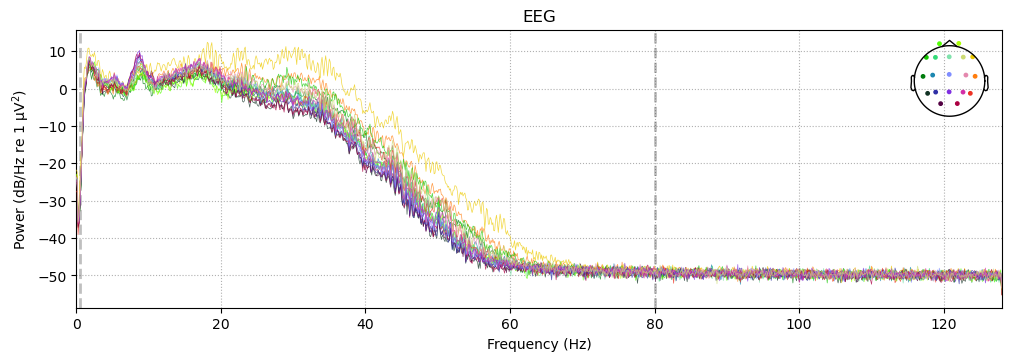

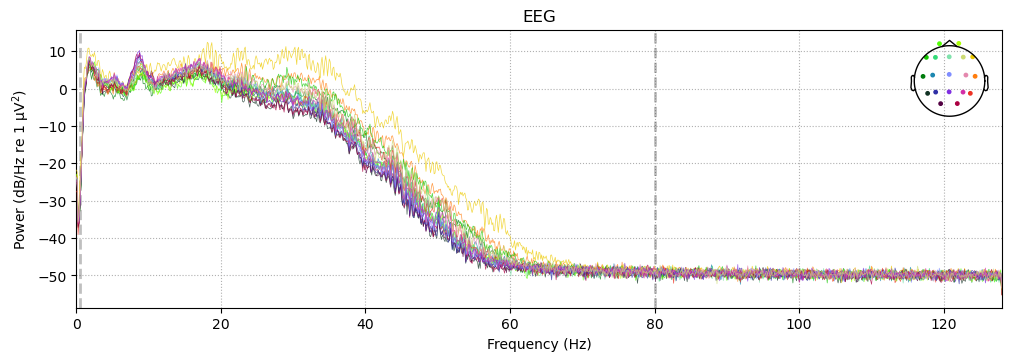

In [14]:
raw.plot_psd(picks=['eeg'])

## 10. Filtrage des données EEG

Chaque fichier subit ensuite les étapes suivantes :
1. **re-référenciation moyenne** (`average reference`)
2. **filtre passe-bande 1–40 Hz**

Le filtrage permet de conserver les bandes EEG d’intérêt tout en supprimant les fréquences très basses et les hautes fréquences moins pertinentes pour cette analyse.

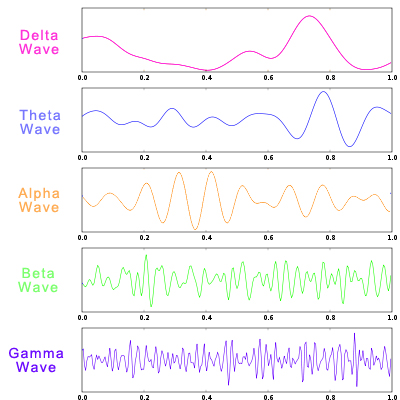

In [15]:
raw_list_rf = [raw.copy()
               .set_eeg_reference(ref_channels='average', verbose=False)    # re-référenciation moyenne
               .filter(l_freq=1, h_freq=40, verbose=False)                  # filtre passe-bande 1–40 Hz
               for raw in raw_list]

print(f"Successfully loaded and processed {len(raw_list_rf)} files with filtering applied.")

Successfully loaded and processed 58 files with filtering applied.


## 11. Séparation des données par groupe

Les enregistrements prétraités sont séparés selon leur groupe d’appartenance :
- **H** = contrôles sains
- **MDD** = participants avec dépression majeure

In [16]:
h_indices = [i for i, f in enumerate(edf_files) if f in h_files]
mdd_indices = [i for i, f in enumerate(edf_files) if f in mdd_files]

raw_list_h = [raw_list_rf[i] for i in h_indices]
raw_list_mdd = [raw_list_rf[i] for i in mdd_indices]

## 12. Comparaison exploratoire de la PSD entre groupes

In [17]:
def plot_group_psd(raw_list, group_name):
    """
    Cette fonction calcule la densité spectrale de puissance moyenne pour chaque groupe, puis affiche la PSD moyenne par canal.  
    Il s’agit d’une étape exploratoire utile pour observer d’éventuelles différences globales entre les groupes.
    """
    psds = []
    for raw in raw_list:
        psd = raw.compute_psd(picks='eeg', fmin=1, fmax=40, n_per_seg=256)  # filtre passe-bande 1–40 Hz
        psd_data, freqs = psd.get_data(return_freqs=True)
        psds.append(psd_data)
    mean_psd = np.mean(psds, axis=0)
    plt.figure()

    for i in range(mean_psd.shape[0]):
        plt.plot(freqs, 10 * np.log10(mean_psd[i, :]), label=f'Ch {i+1}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (dB/Hz)')
    plt.title(f'Average PSD Across {group_name} Files')
    plt.legend()
    plt.grid()
    plt.show()

Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


...

Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


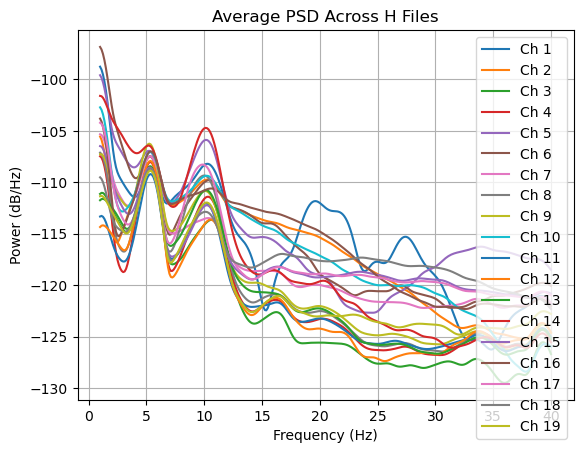

Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


...

Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


Effective window size : 8.000 (s)


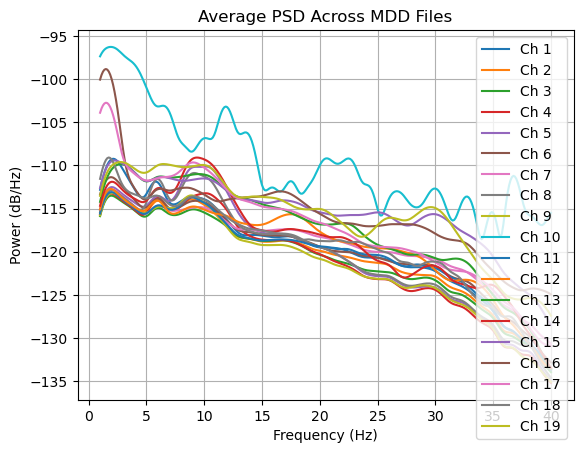

Plotted PSD for 28 H files and 30 MDD files.


In [18]:
plot_group_psd(raw_list_h, 'H')
plot_group_psd(raw_list_mdd, 'MDD')

print(f"Plotted PSD for {len(raw_list_h)} H files and {len(raw_list_mdd)} MDD files.")

## 13. Création des époques

### 13.1 Ancienne méthode de création d'epoch

La cellule suivante correspond à la version de l'auteur principal du projet.  
Elle fonctionnait en ajoutant manuellement chaque époque dans une liste avec `append()`.

**Problème :**
- cette méthode consomme beaucoup de mémoire
- elle devient inefficace pour de grands volumes de données
- elle peut entraîner des erreurs ou corrompre les objets si la mémoire devient insuffisante

Elle est conservée ici à titre de trace méthodologique, mais n’est pas la version finale recommandée.

In [ ]:
"""
# epoch parameter
tmin, tmax = 0, 4
event_id = 1 

# save X and Y data used in deep learning
all_epochs_data = [] 
all_epoch_labels = [] 
all_subject_ids  = []

# H
print("\nProcessing H group epochs...")
for i, raw_h in enumerate(raw_list_h):
    events = mne.make_fixed_length_events(raw_h, id=event_id, duration=tmax, overlap=0)
    epochs_h = mne.Epochs(raw_h, events, event_id, tmin, tmax, baseline=None, preload=True, verbose=False)
    
    for epoch_data in epochs_h.get_data():
        all_epochs_data.append(epoch_data)
        all_epoch_labels.append(0)    # label as 0
        all_subject_ids.append(i)

# MDD
print("\nProcessing MDD group epochs...")
n_h = len(raw_list_h) # offset pour que les IDs MDD ne chevauchent pas les H
for raw_mdd in enumerate(raw_list_mdd):
    events = mne.make_fixed_length_events(raw_mdd, id=event_id, duration=tmax, overlap=0)
    epochs_mdd = mne.Epochs(raw_mdd, events, event_id, tmin, tmax, baseline=None, preload=True, verbose=False)
    
    for epoch_data in epochs_mdd.get_data():
        all_epochs_data.append(epoch_data)
        all_epoch_labels.append(1)    # label as 1
        all_subject_ids.append(n_h + i)

# Save data for deep learning training
X_epochs_data = np.array(all_epochs_data)
y_epoch_labels = np.array(all_epoch_labels)

print(f"\nTotal epochs collected: {X_epochs_data.shape[0]}")
print(f"Shape of X_epochs_data (data for ml/dl): {X_epochs_data.shape}")    # (4308, 19, 1025)
print(f"Shape of y_epoch_labels (labels for ml/dl): {y_epoch_labels.shape}")    # (4308,)
"""


Processing H group epochs...



Processing MDD group epochs...



Total epochs collected: 4308
Shape of X_epochs_data (data for ml/dl): (4308, 19, 1025)
Shape of y_epoch_labels (labels for ml/dl): (4308,)


### 13.2 Nouvelle méthode de création d'epoch

Les signaux EEG continus sont segmentés en époques fixes de **4 secondes**.  
Chaque époque constitue une unité d’analyse indépendante pour l’extraction des caractéristiques.

La méthode retenue ici est plus efficace :
- les époques sont créées séparément pour chaque fichier
- les objets `Epochs` sont stockés dans des listes
- les époques sont ensuite concaténées par groupe
- les labels sont générés automatiquement à partir du groupe d’appartenance

In [ ]:
# Paramètres
tmin, tmax = 0, 4  # époque de 4 secondes

# Listes pour stocker les objets Epochs 
epochs_list_h = []
epochs_list_mdd = []

# Listes pour stocker les IDs de sujet 
subject_ids_h   = []
subject_ids_mdd = []

# Traitement du groupe H
print("\nProcessing H group...")
for i, raw_h in enumerate(raw_list_h):
    # Création d'époques fixes de 4 secondes
    epochs_h = mne.make_fixed_length_epochs(raw_h, duration=tmax, preload=True, verbose=False)
    epochs_list_h.append(epochs_h)
    subject_ids_h.extend([i] * len(epochs_h))
    

# Traitement du groupe MDD 
print("Processing MDD group...")
n_h = len(raw_list_h) # Offset pour que les IDs MDD ne chevauchent pas les H
for i, raw_mdd in enumerate(raw_list_mdd):
     # Création d'époques fixes de 4 secondes
    epochs_mdd = mne.make_fixed_length_epochs(raw_mdd, duration=tmax, preload=True, verbose=False)
    epochs_list_mdd.append(epochs_mdd)
    subject_ids_mdd.extend([n_h + i] * len(epochs_mdd))

# Concaténation des époques pour chaque groupe
epochs_h_all = mne.concatenate_epochs(epochs_list_h)
epochs_mdd_all = mne.concatenate_epochs(epochs_list_mdd)

# Extraction des données numériques pour chaque groupe
X_h = epochs_h_all.get_data()
X_mdd = epochs_mdd_all.get_data()

# Création des labels pour chaque groupe
y_h = np.zeros(len(X_h))      # 0 = groupe H
y_mdd = np.ones(len(X_mdd))   # 1 = groupe MDD

# Combinaison finale des données et des labels
X_epochs_data = np.concatenate([X_h, X_mdd])
y_epoch_labels = np.concatenate([y_h, y_mdd])
subject_ids    = np.array(subject_ids_h + subject_ids_mdd)

print(f"\nTotal epochs collected: {X_epochs_data.shape[0]}")
print(f"Shape of X_epochs_data (data for ml/dl): {X_epochs_data.shape}")
print(f"Shape of y_epoch_labels (labels for ml/dl): {y_epoch_labels.shape}")
print(f"Shape of subject_ids: {subject_ids.shape}")
print(f"Nombre de sujets uniques: {len(np.unique(subject_ids))}") 


Processing H group...


Processing MDD group...


Not setting metadata


2133 matching events found


No baseline correction applied


Not setting metadata


2196 matching events found


No baseline correction applied



Total epochs collected: 4329
Shape of X_epochs_data (data for ml/dl): (4329, 19, 1024)
Shape of y_epoch_labels (labels for ml/dl): (4329,)


## 14. Extraction des caractéristiques de bandpower

Pour chaque epoch EEG, on calcule la densité spectrale de puissance avec la méthode de Welch, puis on extrait la puissance moyenne dans cinq bandes de fréquences classiques :

- **delta** : 1–4 Hz
- **theta** : 4–8 Hz
- **alpha** : 8–13 Hz
- **beta** : 13–30 Hz
- **gamma** : 30–40 Hz

Pour chaque époque :
- la PSD est calculée séparément pour chaque canal
- la puissance moyenne est calculée dans chaque bande
- les valeurs de tous les canaux et de toutes les bandes sont concaténées dans un vecteur de caractéristiques

Avec 19 canaux et 5 bandes, chaque epoch produit :
**19 × 5 = 95 caractéristiques**

In [21]:
bands = {
    'delta': [1, 4],
    'theta': [4, 8],
    'alpha': [8, 13],
    'beta': [13, 30],
    'gamma': [30, 40]
}

X_features = []

# Calcul de la puissance moyenne dans chaque bande de fréquence pour chaque epoch
for epoch in X_epochs_data:
    psds, freqs = psd_array_welch(epoch, sfreq=256, fmin=1, fmax=40, n_fft=epoch.shape[1], verbose=False)

    band_features = []
    for band, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        if np.any(idx):
            band_power = psds[:, idx].mean(axis=1)  # moyenne pour chaque canal
        else:
            band_power = np.zeros(epoch.shape[0])
        
        # Ajouter les valeurs de tous les canaux pour cette bande
        band_features.extend(band_power)

    X_features.append(band_features)

X_features = np.array(X_features)
y_labels = np.array(y_epoch_labels)

print("X_features shape:", X_features.shape)  # (4329, 95)
print("y_labels shape:", y_labels.shape)      # (4329,)


X_features shape: (4329, 95)
y_labels shape: (4329,)


## 15. Sauvegarde des sorties

Les données finales sont sauvegardées dans le dossier de sortie pour être réutilisées dans les étapes ultérieures d’analyse ou de classification.

Fichiers enregistrés :
- `X_epochs_data.npy` : données EEG epoch brutes
- `X_features.npy` : caractéristiques spectrales (bandpower)
- `y_epoch_labels.npy` : étiquettes de groupe

In [ ]:
os.makedirs(output_data_dir, exist_ok=True)

np.save(os.path.join(output_data_dir, "subject_ids.npy"), subject_ids)
np.save(os.path.join(output_data_dir, "X_epochs_data.npy"), X_epochs_data)
np.save(os.path.join(output_data_dir, "X_features.npy"), X_features)
np.save(os.path.join(output_data_dir, "y_epoch_labels.npy"), y_epoch_labels)

print(f"Saved all features to {output_data_dir}")

Saved all features to /Users/oceanevallee/PSY3019/Projet final/Vallee_ProjetFinal/output_data


# Résumé du pipeline

En résumé, ce notebook effectue les étapes suivantes :

1. **Importation des librairies**  
   Chargement des bibliothèques nécessaires au traitement EEG, à la manipulation des fichiers, aux calculs numériques et à la visualisation.

2. **Définition des dossiers d’entrée et de sortie**  
   Spécification des chemins vers les données brutes et vers le dossier où seront sauvegardées les sorties prétraitées.

3. **Chargement du jeu de données**  
   Repérage des fichiers EEG `.edf`, tri des fichiers selon le groupe, chargement des enregistrements et identification des canaux communs entre tous les participants.

4. **Visualisation des données brutes**  
   Inspection visuelle d’un enregistrement EEG brut afin de vérifier la qualité générale du signal et la présence éventuelle d’artefacts.

5. **Inspection des métadonnées**  
   Vérification des informations associées aux enregistrements EEG, comme les noms de canaux, la fréquence d’échantillonnage et la référence utilisée.

6. **Sélection des canaux communs**  
   Conservation des 19 canaux EEG présents dans tous les fichiers afin d’assurer l’uniformité des données entre les participants.

7. **Renommage des canaux**  
   Simplification des noms de canaux pour les rendre compatibles avec le montage standard 10-20.

8. **Visualisation de la disposition des électrodes**  
   Association des canaux au montage standard et vérification visuelle de leur position sur le scalp.

9. **Visualisation du spectre de puissance**  
   Observation de la densité spectrale de puissance des signaux afin d’évaluer la distribution fréquentielle avant le traitement final.

10. **Filtrage des données EEG**  
    Application d’une re-référenciation moyenne et d’un filtre passe-bande de 1 à 40 Hz sur tous les enregistrements.

11. **Séparation des données par groupe**  
    Répartition des enregistrements prétraités selon leur groupe d’appartenance : H ou MDD.

12. **Comparaison exploratoire de la PSD entre groupes**  
    Calcul et visualisation de la densité spectrale moyenne pour comparer de façon exploratoire les profils spectraux des deux groupes.

13. **Création des époques**  
    Segmentation des signaux continus en segments fixes de 4 secondes pour préparer les données à l’extraction de caractéristiques.
    
    13.1 **Ancienne méthode de création d’epoch**  
    Présentation d’une première version de l’épocage, conservée à titre méthodologique, mais moins efficace sur le plan de la mémoire.
    
    13.2 **Nouvelle méthode de création d’epoch**  
    Mise en place d’une méthode plus efficace consistant à créer les époques par fichier, à les concaténer par groupe, puis à générer les labels correspondants.

14. **Extraction des caractéristiques de bandpower**  
    Calcul de la puissance moyenne dans les bandes de fréquences classiques (delta, theta, alpha, beta, gamma) pour chaque époque et chaque canal.

15. **Sauvegarde des sorties**  
    Enregistrement des données EEG épocées, des caractéristiques extraites et des labels dans des fichiers `.npy` pour les analyses ultérieures.